In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3.common.env_checker import check_env
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor
import matplotlib.pyplot as plt

In [81]:
tickers = ["AAPL", "MSFT", "TSLA", "GOOGL", "AMZN"]

data = yf.download(
    tickers,
    start="2020-01-01",
    end="2022-12-31",
    interval="1d"
)

# Séparer prix et volume
price_df = data["Close"].copy()
volume_df = data["Volume"].copy()

print(price_df.head())
print(volume_df.head())


[*********************100%***********************]  5 of 5 completed

Ticker           AAPL       AMZN      GOOGL        MSFT       TSLA
Date                                                              
2020-01-02  72.400520  94.900497  67.873024  152.158401  28.684000
2020-01-03  71.696632  93.748497  67.517967  150.263733  29.534000
2020-01-06  72.267952  95.143997  69.317596  150.652176  30.102667
2020-01-07  71.928070  95.343002  69.183701  149.278503  31.270666
2020-01-08  73.085114  94.598503  69.676125  151.656296  32.809334
Ticker           AAPL      AMZN     GOOGL      MSFT       TSLA
Date                                                          
2020-01-02  135480400  80580000  27278000  22622100  142981500
2020-01-03  146322800  75288000  23408000  21116200  266677500
2020-01-06  118387200  81236000  46768000  20813700  151995000
2020-01-07  108872000  80898000  34330000  21634100  268231500
2020-01-08  132079200  70160000  35314000  27746500  467164500


In [82]:
def prepare_features(price_df: pd.DataFrame, volume_df: pd.DataFrame):
    tickers = list(price_df.columns)
    feats = {}

    for t in tickers:
        px = price_df[t].copy()
        vol = volume_df[t].copy()

        df_t = pd.DataFrame(index=price_df.index)
        df_t["close"] = px

        # Tout est décalé d'un jour pour que la décision à t
        # n'utilise que l'information disponible avant l'ouverture de t
        df_t["ret_1"] = px.pct_change(1).shift(1)
        df_t["ret_5"] = px.pct_change(5).shift(1)
        df_t["vol_20"] = px.pct_change().rolling(20).std().shift(1) * np.sqrt(252)

        vol_mean = vol.rolling(20).mean().shift(1)
        vol_std = vol.rolling(20).std().shift(1)
        df_t["vol_z"] = (vol.shift(1) - vol_mean) / (vol_std + 1e-8)

        feats[t] = df_t

    panel = pd.concat(feats, axis=1)
    panel = panel.dropna().copy()
    return panel

In [83]:
prepare_features(price_df, volume_df).head()

AAPL                                                AMZN  \
                close     ret_1     ret_5    vol_20     vol_z       close   
Date                                                                        
2020-02-03  74.403671 -0.044339 -0.027646  0.280647  1.901335  100.209999   
2020-02-04  76.860023 -0.002746 -0.000939  0.277977  1.006773  102.483498   
2020-02-05  77.486755  0.033014  0.003651  0.298561 -0.176367  101.993500   
2020-02-06  78.393105  0.008154 -0.008910  0.297503 -0.762368  102.511497   
2020-02-07  77.327538  0.011697  0.004137  0.295519 -1.110964  103.963997   

                                                    ...        MSFT            \
               ret_1     ret_5    vol_20     vol_z  ...       close     ret_1   
Date                                                ...                         
2020-02-03  0.073791  0.079006  0.305346  4.042467  ...  165.193512 -0.014759   
2020-02-04 -0.002250  0.096186  0.300824  0.607842  ...  170.631149  0.024379   
2020-02-05  0.022687  0.105987  0.305970  0.376059  ...  170.422684  0.032917   
2020-02-06 -0.004781  0.097885  0.307475  0.054755  ...  173.956223 -0.001222   
2020-02-07  0.005079  0.095981  0.304550 -0.351393  ...  174.202560  0.020734   

                                               TSLA                      \
               ret_5    vol_20     vol_z      close     ret_1     ret_5   
Date                                                                      
2020-02-03  0.031447  0.205895  1.196135  52.000000  0.015231  0.151818   
2020-02-04  0.074563  0.210711  0.370310  59.137333  0.198949  0.397799   
2020-02-05  0.088602  0.232776  1.073299  48.980000  0.137256  0.564756   
2020-02-06  0.070578  0.227444  1.275875  49.930668 -0.171758  0.264566   
2020-02-07  0.062797  0.230635 -0.142985  49.871334  0.019409  0.168771   

                                
              vol_20     vol_z  
Date                            
2020-02-03  0.597231 -0.603796  
2020-02-04  0.868485  2.806279  
2020-02-05  0.946612  2.994748  
2020-02-06  1.199377  1.713067  
2020-02-07  1.196184  1.019119  

[5 rows x 25 columns]

In [84]:
class MultiAssetTradingEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(
        self,
        features_panel,
        tickers,
        initial_cash=100000.0,
        transaction_cost=0.001,
        short_borrow_rate=0.03,   # coût annuel du short
        max_gross_exposure=1.0,   # somme(|poids|) max
        max_steps=252,
        random_start=True,
    ):
        super().__init__()

        self.data = features_panel.copy()
        self.tickers = list(tickers)
        self.n_assets = len(self.tickers)

        self.initial_cash = float(initial_cash)
        self.transaction_cost = float(transaction_cost)
        self.short_borrow_rate = float(short_borrow_rate)
        self.max_gross_exposure = float(max_gross_exposure)
        self.max_steps = int(max_steps)
        self.random_start = bool(random_start)

        # Features par actif
        self.asset_features = ["ret_1", "ret_5", "vol_20", "vol_z"]
        self.n_features_per_asset = len(self.asset_features)

        # Observation = features multi-actifs + poids actifs + poids cash
        self.obs_dim = self.n_assets * self.n_features_per_asset + self.n_assets + 1

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(self.obs_dim,),
            dtype=np.float32,
        )

        # Action continue :
        # - n_assets valeurs signées -> direction / intensité long-short
        # - 1 valeur -> budget d'exposition brute total
        self.action_space = spaces.Box(
            low=-5.0,
            high=5.0,
            shape=(self.n_assets + 1,),
            dtype=np.float32,
        )

        self.dates = self.data.index.unique().tolist()
        self._reset_internal_state()

    def _reset_internal_state(self):
        self.current_step = 0
        self.start_step = 0
        self.end_step = min(len(self.dates) - 2, self.max_steps)

        self.cash = self.initial_cash
        self.cash_weight = 1.0
        self.weights = np.zeros(self.n_assets, dtype=np.float64)
        self.portfolio_value = self.initial_cash
        self.portfolio_values = [self.initial_cash]
        self.n_trades = 0

    @staticmethod
    def _sigmoid(x):
        return 1.0 / (1.0 + np.exp(-x))

    def _action_to_target_weights(self, action):
        action = np.asarray(action, dtype=np.float64).reshape(-1)

        if action.shape[0] != self.n_assets + 1:
            raise ValueError(
                f"Action de taille {action.shape[0]} reçue, attendu {self.n_assets + 1}"
            )

        # Partie 1 : score signé par actif
        signed_scores = np.tanh(np.clip(action[:self.n_assets], -5.0, 5.0))

        # Partie 2 : budget d'exposition brute entre 0 et max_gross_exposure
        gross_budget = (
            self._sigmoid(np.clip(action[-1], -5.0, 5.0)) * self.max_gross_exposure
        )

        l1_norm = np.abs(signed_scores).sum()

        if l1_norm < 1e-12 or gross_budget < 1e-12:
            risky_weights = np.zeros(self.n_assets, dtype=np.float64)
        else:
            risky_weights = signed_scores / l1_norm
            risky_weights = risky_weights * gross_budget

        # cash résiduel
        cash_weight = 1.0 - np.abs(risky_weights).sum()
        cash_weight = max(float(cash_weight), 0.0)

        return risky_weights, cash_weight

    def _get_prices(self, step):
        date = self.dates[step]
        return np.array(
            [self.data.loc[date, (t, "close")] for t in self.tickers],
            dtype=np.float64,
        )

    def _get_feature_vector(self, step):
        date = self.dates[step]
        feats = []

        for t in self.tickers:
            for f in self.asset_features:
                feats.append(self.data.loc[date, (t, f)])

        feats = np.array(feats, dtype=np.float32)

        obs = np.concatenate(
            [
                feats,
                self.weights.astype(np.float32),
                np.array([self.cash_weight], dtype=np.float32),
            ],
            axis=0,
        )
        return obs

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._reset_internal_state()

        max_start = max(0, len(self.dates) - self.max_steps - 1)
        if self.random_start and max_start > 0:
            self.start_step = int(self.np_random.integers(0, max_start + 1))
        else:
            self.start_step = 0

        self.current_step = self.start_step
        self.end_step = min(len(self.dates) - 2, self.current_step + self.max_steps)

        self.portfolio_value = self.initial_cash
        self.weights = np.zeros(self.n_assets, dtype=np.float64)
        self.cash_weight = 1.0
        self.cash = self.initial_cash
        self.portfolio_values = [self.initial_cash]
        self.n_trades = 0

        obs = self._get_feature_vector(self.current_step)
        info = {"portfolio_value": self.portfolio_value}
        return obs, info

    def step(self, action):
        target_weights, target_cash_weight = self._action_to_target_weights(action)

        prices_t = self._get_prices(self.current_step)
        old_value = self.portfolio_value

        prev_allocation = np.concatenate([self.weights, [self.cash_weight]])
        target_allocation = np.concatenate([target_weights, [target_cash_weight]])

        turnover = 0.5 * np.abs(target_allocation - prev_allocation).sum()
        trading_cost = turnover * self.transaction_cost * old_value

        # Passage au jour suivant
        self.current_step += 1
        prices_tp1 = self._get_prices(self.current_step)

        asset_returns = (prices_tp1 / prices_t) - 1.0

        # Rendement portefeuille long/short
        gross_portfolio_return = float(np.dot(target_weights, asset_returns))

        # Coût d'emprunt journalier sur la partie short
        short_exposure = float(np.abs(np.minimum(target_weights, 0.0)).sum())
        borrow_cost = old_value * short_exposure * (self.short_borrow_rate / 252.0)

        new_value = old_value * (1.0 + gross_portfolio_return) - trading_cost - borrow_cost
        new_value = max(new_value, 1e-8)

        self.weights = target_weights
        self.cash_weight = target_cash_weight
        self.cash = new_value * self.cash_weight
        self.portfolio_value = new_value
        self.portfolio_values.append(new_value)

        if turnover > 1e-8:
            self.n_trades += 1

        reward = float(np.log(new_value / max(old_value, 1e-8)))

        terminated = bool(new_value <= self.initial_cash * 0.5)
        truncated = bool(self.current_step >= self.end_step)

        obs = self._get_feature_vector(self.current_step)
        info = {
            "portfolio_value": float(new_value),
            "daily_return_gross": float(gross_portfolio_return),
            "daily_return_net": float(new_value / max(old_value, 1e-8) - 1.0),
            "turnover": float(turnover),
            "short_exposure": float(short_exposure),
            "gross_exposure": float(np.abs(target_weights).sum()),
            "net_exposure": float(target_weights.sum()),
            "n_trades": int(self.n_trades),
            "weights": self.weights.copy(),
            "cash_weight": float(self.cash_weight),
            "asset_returns": asset_returns.copy(),
            "date": self.dates[self.current_step],
        }
        return obs, reward, terminated, truncated, info

    def render(self):
        print(
            f"Step={self.current_step}, "
            f"Value={self.portfolio_value:.2f}, "
            f"CashW={self.cash_weight:.2%}, "
            f"GrossExp={np.abs(self.weights).sum():.2%}, "
            f"NetExp={self.weights.sum():.2%}"
        )

In [85]:
panel = prepare_features(price_df[tickers], volume_df[tickers])

env = MultiAssetTradingEnv(
    features_panel=panel,
    tickers=tickers,
    initial_cash=100000,
    transaction_cost=0.001,
    short_borrow_rate=0.03,
    max_gross_exposure=1.0,
    max_steps=252,
    random_start=True,
)

check_env(env, warn=True)
print("Environnement long/short valide pour SB3.")

Environnement long/short valide pour SB3.


C:\ECE\Inge_4\S2\Intelligence artificielle FIN\Projet2\rl_env\lib\site-packages\stable_baselines3\common\env_checker.py:453: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


In [86]:
def make_env():
    return MultiAssetTradingEnv(
        features_panel=panel,
        tickers=tickers,
        initial_cash=100000,
        transaction_cost=0.001,
        short_borrow_rate=0.03,
        max_gross_exposure=1.0,
        max_steps=252,
        random_start=True,
    )

train_env = DummyVecEnv([make_env])
train_env = VecMonitor(train_env)

model = PPO(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.001,
    vf_coef=0.5,
    verbose=1,
    seed=42,
)

model.learn(total_timesteps=200_000)

Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 252      |
|    ep_rew_mean     | -0.0926  |
| time/              |          |
|    fps             | 372      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 252         |
|    ep_rew_mean          | -0.112      |
| time/                   |             |
|    fps                  | 258         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.011607668 |
|    clip_fraction        | 0.105       |
|    clip_range           | 0.2         |
|    entropy_loss         | -8.52       |
|    explained_variance   | -4.49       |
|    learning

In [87]:
model.save("ppo_multiasset_longshort")

In [124]:
model = PPO.load("ppo_multiasset_longshort")


In [88]:
def equal_weight_buy_and_hold(price_df, tickers):
    px = price_df[tickers].copy().dropna()
    daily_returns = px.pct_change().dropna()
    ew_returns = daily_returns.mean(axis=1)


    total_return = (1 + ew_returns).prod() - 1
    sharpe = 0.0
    if ew_returns.std() > 1e-12:
        sharpe = ew_returns.mean() / ew_returns.std() * np.sqrt(252)

    equity = (1 + ew_returns).cumprod()
    dd = equity / equity.cummax() - 1
    max_drawdown = dd.min()

    return {
        "total_return": float(total_return),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_drawdown)
    }

baseline = equal_weight_buy_and_hold(price_df.loc[panel.index], tickers)
print(baseline)

{'total_return': 0.5897228605753355, 'sharpe': 0.6215681710380196, 'max_drawdown': -0.45842418712140454}


In [89]:
def evaluate_trained_model(model, env, deterministic=True):
    obs, info = env.reset()
    done = False

    portfolio_values = [info["portfolio_value"]]
    dates = [env.dates[env.current_step]]
    rewards = []

    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        rewards.append(reward)
        portfolio_values.append(info["portfolio_value"])
        dates.append(env.dates[env.current_step])

    values = np.array(portfolio_values, dtype=np.float64)
    returns = pd.Series(values).pct_change().dropna()

    total_return = values[-1] / values[0] - 1.0

    sharpe = 0.0
    if returns.std() > 1e-12:
        sharpe = returns.mean() / returns.std() * np.sqrt(252)

    running_max = np.maximum.accumulate(values)
    drawdowns = values / running_max - 1.0
    max_drawdown = drawdowns.min()

    results = {
        "total_return": float(total_return),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_drawdown),
        "final_portfolio_value": float(values[-1]),
        "avg_reward": float(np.mean(rewards)) if len(rewards) > 0 else 0.0,
        "n_steps": len(rewards),
        "n_trades": info.get("n_trades", None),
        "portfolio_values": values,
        "dates": dates,
    }

    return results

## Test du model sur données jamais vue


In [90]:
tickers1 = ["AAPL", "MSFT", "TSLA", "GOOGL", "AMZN"]

data = yf.download(
    tickers1,
    start="2023-01-01",
    end="2023-07-01",
    interval="1d"
)

# Séparer prix et volume
price_df = data["Close"].copy()
volume_df = data["Volume"].copy()

tickers = tickers1.copy()

print(tickers)
print(price_df.head())
print(volume_df.head())


[*********************100%***********************]  5 of 5 completed

['AAPL', 'MSFT', 'TSLA', 'GOOGL', 'AMZN']
Ticker            AAPL       AMZN      GOOGL        MSFT        TSLA
Date                                                                
2023-01-03  123.096016  85.820000  88.389458  233.452805  108.099998
2023-01-04  124.365662  85.139999  87.357986  223.240829  113.639999
2023-01-05  123.046814  83.120003  85.493385  216.624481  110.339996
2023-01-06  127.574211  86.080002  86.624054  219.177460  113.059998
2023-01-09  128.095810  87.360001  87.298477  221.311447  119.769997
Ticker           AAPL      AMZN     GOOGL      MSFT       TSLA
Date                                                          
2023-01-03  112117500  76706000  28131200  25740000  231402800
2023-01-04   89113600  68885100  34854800  50623400  180389000
2023-01-05   80962700  67930800  27194400  39585600  157986300
2023-01-06   87754700  83303400  41381500  43613600  220911100
2023-01-09   70790800  65266100  29003900  27369800  190284000


In [91]:
panel = prepare_features(price_df[tickers], volume_df[tickers])

In [92]:
panel = prepare_features(price_df[tickers], volume_df[tickers])

test_env = MultiAssetTradingEnv(
    features_panel=panel,
    tickers=tickers,
    initial_cash=100000,
    transaction_cost=0.001,
    short_borrow_rate=0.03,
    max_gross_exposure=1.0,
    max_steps=252,
    random_start=False,
)

results = evaluate_trained_model(model, test_env)

print("Résultats du modèle long/short :")
print(f"Total Return     : {results['total_return']:.2%}")
print(f"Sharpe Ratio     : {results['sharpe']:.3f}")
print(f"Max Drawdown     : {results['max_drawdown']:.2%}")
print(f"Valeur finale    : {results['final_portfolio_value']:.2f}")
print(f"Nombre de trades : {results['n_trades']}")

Résultats du modèle long/short :
Total Return     : -1.10%
Sharpe Ratio     : -0.185
Max Drawdown     : -7.81%
Valeur finale    : 98903.40
Nombre de trades : 101


In [93]:
baseline = equal_weight_buy_and_hold(price_df.loc[panel.index], tickers1)

print("Baseline :")
print(f"Total Return : {baseline['total_return']:.2%}")
print(f"Sharpe       : {baseline['sharpe']:.3f}")
print(f"Max DD       : {baseline['max_drawdown']:.2%}")

Baseline :
Total Return : 25.84%
Sharpe       : 2.471
Max DD       : -9.71%


In [94]:
print("Comparaison IA vs baseline")
print(f"Surperformance return : {results['total_return'] - baseline['total_return']:.2%}")
print(f"Différence Sharpe     : {results['sharpe'] - baseline['sharpe']:.3f}")

Comparaison IA vs baseline
Surperformance return : -26.94%
Différence Sharpe     : -2.656


In [95]:
def get_ppo_portfolio_curve(model, env, deterministic=True):
    obs, info = env.reset()
    done = False

    portfolio_values = [info["portfolio_value"]]
    dates = [env.dates[env.current_step]]

    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        portfolio_values.append(info["portfolio_value"])
        dates.append(env.dates[env.current_step])

    curve = pd.DataFrame({
        "date": dates,
        "ppo_portfolio": portfolio_values,
    }).set_index("date")

    return curve

In [96]:
def get_buy_and_hold_curve(price_df, tickers, initial_cash=100000):
    px = price_df[tickers].copy().dropna()

    # Prix initiaux
    first_prices = px.iloc[0]

    # Capital réparti également
    alloc_per_asset = initial_cash / len(tickers)

    # Nombre de parts achetées au départ
    shares = alloc_per_asset / first_prices

    # Valeur du portefeuille au fil du temps
    portfolio_values = (px * shares).sum(axis=1)

    curve = pd.DataFrame({
        "buy_hold_portfolio": portfolio_values
    })

    return curve

In [97]:
test_prices = price_df.loc[panel.index, tickers1].copy()


In [98]:
ppo_curve = get_ppo_portfolio_curve(model, test_env)
bh_curve = get_buy_and_hold_curve(test_prices, tickers1, initial_cash=100000)

In [99]:
comparison = ppo_curve.join(bh_curve, how="inner")
print(comparison.head())

            ppo_portfolio  buy_hold_portfolio
2023-02-02  100000.000000       100000.000000
2023-02-03   99328.763230        97961.466155
2023-02-06   99235.255246        97419.185046
2023-02-07   99720.506966        99707.236080
2023-02-08  100758.107855        97858.327807


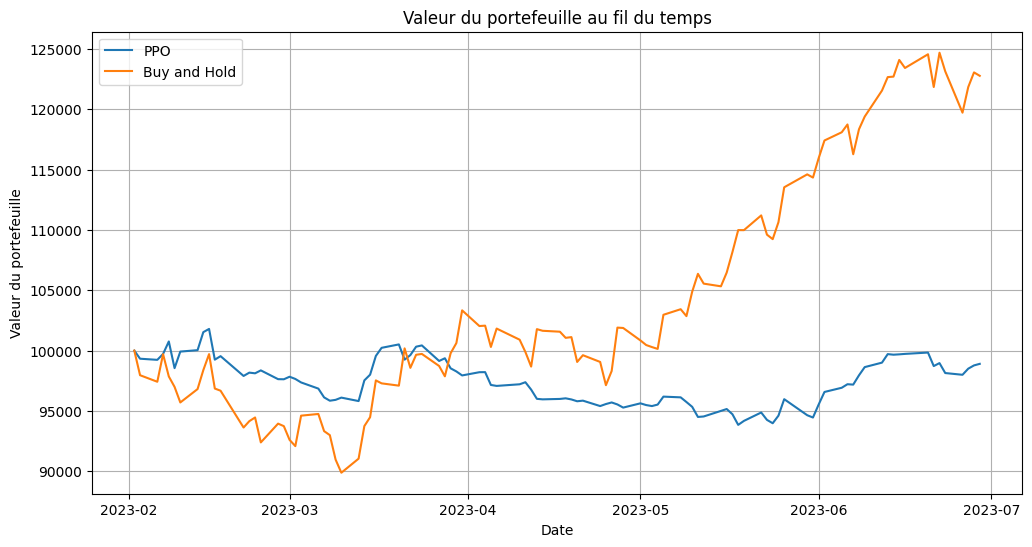

In [100]:
plt.figure(figsize=(12, 6))
plt.plot(comparison.index, comparison["ppo_portfolio"], label="PPO")
plt.plot(comparison.index, comparison["buy_hold_portfolio"], label="Buy and Hold")
plt.title("Valeur du portefeuille au fil du temps")
plt.xlabel("Date")
plt.ylabel("Valeur du portefeuille")
plt.legend()
plt.grid(True)
plt.show()

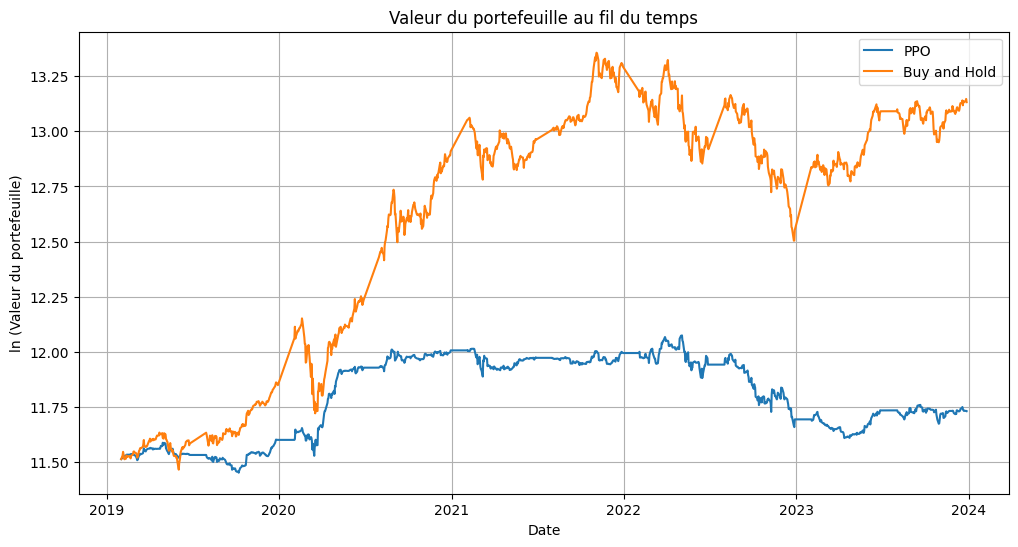

In [119]:
plt.figure(figsize=(12, 6))
plt.plot(comparison.index, np.log(comparison["ppo_portfolio"]), label="PPO")
plt.plot(comparison.index, np.log(comparison["buy_hold_portfolio"]), label="Buy and Hold")
plt.title("Valeur du portefeuille au fil du temps")
plt.xlabel("Date")
plt.ylabel("ln (Valeur du portefeuille)")
plt.legend()
plt.grid(True)
plt.show()

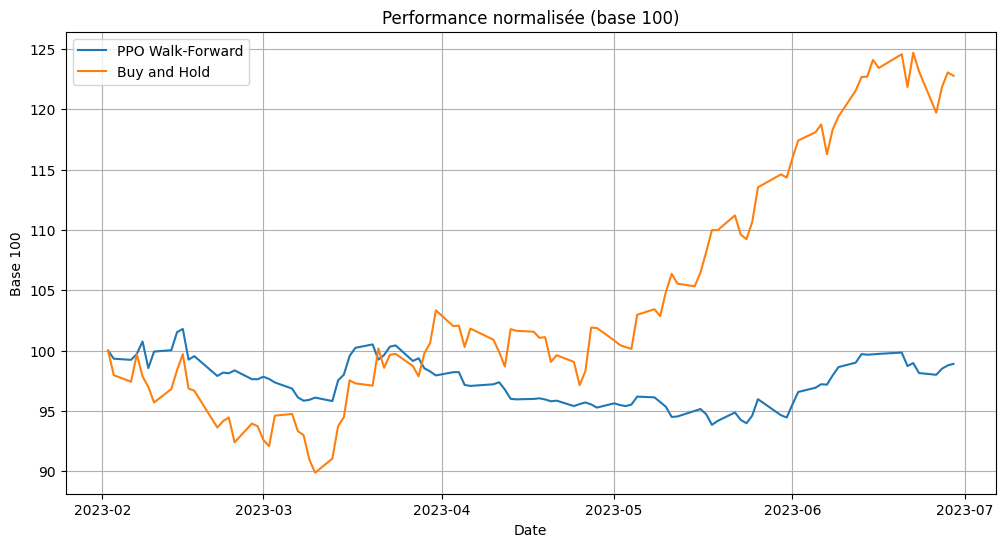

In [102]:
comparison_norm = comparison / comparison.iloc[0] * 100

plt.figure(figsize=(12, 6))
plt.plot(comparison_norm.index, comparison_norm["ppo_portfolio"], label="PPO Walk-Forward")
plt.plot(comparison_norm.index, comparison_norm["buy_hold_portfolio"], label="Buy and Hold")
plt.title("Performance normalisée (base 100)")
plt.xlabel("Date")
plt.ylabel("Base 100")
plt.legend()
plt.grid(True)
plt.show()

In [103]:
def debug_run(model, env, deterministic=True, max_rows=20):
    obs, info = env.reset()
    done = False
    rows = []

    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        asset_returns = np.asarray(info["asset_returns"], dtype=float)
        max_abs_asset_move = np.max(np.abs(asset_returns))
        gross_exposure = float(info["gross_exposure"])
        port_ret = float(info["daily_return_net"])

        theoretical_bound = gross_exposure * max_abs_asset_move

        rows.append({
            "date": info["date"],
            "portfolio_return": port_ret,
            "gross_exposure": gross_exposure,
            "max_abs_asset_move": max_abs_asset_move,
            "theoretical_bound": theoretical_bound,
            "bound_violation": abs(port_ret) > theoretical_bound + 0.02,
            "short_exposure": float(info["short_exposure"]),
            "turnover": float(info["turnover"]),
            "cash_weight": float(info["cash_weight"]),
        })

    df = pd.DataFrame(rows)
    print("Nb jours:", len(df))
    print("Violations de borne:", df["bound_violation"].sum())
    display(df.sort_values("portfolio_return", ascending=False).head(max_rows))
    display(df.sort_values("portfolio_return", ascending=True).head(max_rows))
    return df

In [104]:
df_debug = debug_run(model, test_env)

Nb jours: 101
Violations de borne: 0


,date,portfolio_return,gross_exposure,max_abs_asset_move,theoretical_bound,bound_violation,short_exposure,turnover,cash_weight
26,2023-03-14,0.017892,0.556204,0.050321,0.027989,False,0.045444,0.344227,0.443796
28,2023-03-16,0.015846,0.788084,0.043804,0.034521,False,0.182520,0.335523,0.211916
7,2023-02-14,0.014946,0.604413,0.075062,0.045368,False,0.239295,0.507822,0.395587
78,2023-05-26,0.014435,0.614340,0.047162,0.028974,False,0.146511,0.123312,0.385660
5,2023-02-10,0.013919,0.879691,0.050309,0.044256,False,0.301406,0.255009,0.120309
81,2023-06-01,0.011520,0.842458,0.018162,0.015301,False,0.000000,0.275628,0.157542
82,2023-06-02,0.010792,0.865175,0.031081,0.026891,False,0.000000,0.031907,0.134825
3,2023-02-08,0.010405,0.288708,0.076830,0.022181,False,0.220111,0.394656,0.711292
86,2023-06-08,0.007929,0.369340,0.045821,0.016923,False,0.073059,0.091702,0.630660
74,2023-05-22,0.007380,0.425628,0.048462,0.020627,False,0.069933,0.202837,0.574372


,date,portfolio_return,gross_exposure,max_abs_asset_move,theoretical_bound,bound_violation,short_exposure,turnover,cash_weight
9,2023-02-16,-0.025000,0.807546,0.056946,0.045986,False,0.039860,0.473009,0.192454
4,2023-02-09,-0.021932,0.812561,0.043876,0.035652,False,0.331116,0.768893,0.187439
11,2023-02-21,-0.016489,0.633405,0.052518,0.033265,False,0.096692,0.398552,0.366595
79,2023-05-30,-0.013858,0.832172,0.041363,0.034421,False,0.345164,0.652595,0.167828
35,2023-03-27,-0.012825,0.839158,0.028263,0.023717,False,0.092230,0.248183,0.160842
31,2023-03-21,-0.012544,0.730046,0.078199,0.057089,False,0.412476,0.042740,0.269954
94,2023-06-21,-0.011210,0.842023,0.054618,0.045990,False,0.000000,0.110621,0.157977
42,2023-04-05,-0.010817,0.575131,0.036660,0.021084,False,0.090681,0.103947,0.424869
72,2023-05-18,-0.009286,0.556205,0.022944,0.012761,False,0.556205,0.271542,0.443795
67,2023-05-11,-0.008800,0.360583,0.043132,0.015553,False,0.360583,0.231749,0.639417



# Mise en place d'un entrainement de 5 ans tout les 6 mois pendant 5ans

In [105]:
tickers = ["AAPL", "MSFT", "TSLA", "GOOGL", "AMZN"]

data = yf.download(
    tickers,
    start="2014-01-01",
    end="2025-12-31",
    interval="1d"
)

# Séparer prix et volume
price_df = data["Close"].copy()
volume_df = data["Volume"].copy()

print(price_df.head())
print(volume_df.head())


[*********************100%***********************]  5 of 5 completed

Ticker           AAPL       AMZN      GOOGL       MSFT       TSLA
Date                                                             
2014-01-02  17.140663  19.898500  27.627514  30.760923  10.006667
2014-01-03  16.764153  19.822001  27.425976  30.553982   9.970667
2014-01-06  16.855566  19.681499  27.731760  29.908293   9.800000
2014-01-07  16.735020  19.901501  28.266380  30.140078   9.957333
2014-01-08  16.841002  20.096001  28.325203  29.602005  10.085333
Ticker           AAPL      AMZN      GOOGL      MSFT      TSLA
Date                                                          
2014-01-02  234684800  42756000   72783144  30632200  92826000
2014-01-03  392467600  44204000   66601332  31134800  70425000
2014-01-06  412610800  63412000   70701228  43603700  80416500
2014-01-07  317209200  38320000  102001896  35802800  75511500
2014-01-08  258529600  46330000   89610300  59971700  92448000


In [106]:
def build_walk_forward_windows(first_train_start="2014-01-01", n_windows=10, train_years=5, test_months=6):
    windows = []
    current_train_start = pd.Timestamp(first_train_start)

    for window_id in range(n_windows):
        train_start = current_train_start
        train_end = train_start + pd.DateOffset(years=train_years) - pd.DateOffset(days=1)
        test_start = train_end + pd.DateOffset(days=1)
        test_end = test_start + pd.DateOffset(months=test_months) - pd.DateOffset(days=1)

        windows.append({
            "window_id": window_id,
            "train_start": train_start,
            "train_end": train_end,
            "test_start": test_start,
            "test_end": test_end,
        })

        current_train_start = current_train_start + pd.DateOffset(months=test_months)

    return windows

windows = build_walk_forward_windows(
    first_train_start="2014-01-01",
    n_windows=10,
    train_years=5,
    test_months=6,
)

In [107]:
for w in windows:
    deb_ent = w["train_start"].strftime("%Y-%m-%d")
    fint_ent = w["train_end"].strftime("%Y-%m-%d")

    price_df_per = price_df.loc[deb_ent:fint_ent]
    volume_df_per = volume_df.loc[deb_ent:fint_ent]
    panel = prepare_features(price_df_per[tickers], volume_df_per[tickers])

    env = MultiAssetTradingEnv(
        features_panel=panel,
        tickers=tickers,
        initial_cash=100000,
        transaction_cost=0.001,
        short_borrow_rate=0.03,
        max_gross_exposure=1.0,
        max_steps=252,
        random_start=True,
    )

    check_env(env, warn=True)
    print(f"Environnement valide pour SB3. Entrainement {w['window_id']}")

    def make_env(panel=panel):
        return MultiAssetTradingEnv(
            features_panel=panel,
            tickers=tickers,
            initial_cash=100000,
            transaction_cost=0.001,
            short_borrow_rate=0.03,
            max_gross_exposure=1.0,
            max_steps=252,
            random_start=True,
        )

    train_env = DummyVecEnv([make_env])
    train_env = VecMonitor(train_env)

    print(f"Entrainement du modèle {w['window_id']} de {deb_ent} -> {fint_ent}")

    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        learning_rate=3e-4,
        n_steps=1024,
        batch_size=64,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.001,
        vf_coef=0.5,
        verbose=1,
        seed=42,
    )

    model.learn(total_timesteps=200_000)
    model.save(f"ppo_multiasset_longshort_periode{w['window_id']}")

C:\ECE\Inge_4\S2\Intelligence artificielle FIN\Projet2\rl_env\lib\site-packages\stable_baselines3\common\env_checker.py:453: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


Environnement valide pour SB3. Entrainement 0
Entrainement du modèle 0 de 2014-01-01 -> 2018-12-31
Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 252      |
|    ep_rew_mean     | -0.14    |
| time/              |          |
|    fps             | 379      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 252         |
|    ep_rew_mean          | -0.146      |
| time/                   |             |
|    fps                  | 350         |
|    iterations           | 2           |
|    time_elapsed         | 5           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.010732904 |
|    clip_fraction        | 0.0894      |
|    clip_range           | 0.2         

C:\ECE\Inge_4\S2\Intelligence artificielle FIN\Projet2\rl_env\lib\site-packages\stable_baselines3\common\env_checker.py:453: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


Environnement valide pour SB3. Entrainement 1
Entrainement du modèle 1 de 2014-07-01 -> 2019-06-30
Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 252      |
|    ep_rew_mean     | -0.0812  |
| time/              |          |
|    fps             | 336      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 252         |
|    ep_rew_mean          | -0.117      |
| time/                   |             |
|    fps                  | 314         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.010041606 |
|    clip_fraction        | 0.0809      |
|    clip_range           | 0.2         

C:\ECE\Inge_4\S2\Intelligence artificielle FIN\Projet2\rl_env\lib\site-packages\stable_baselines3\common\env_checker.py:453: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


...

Environnement valide pour SB3. Entrainement 7
Entrainement du modèle 7 de 2017-07-01 -> 2022-06-30
Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 252      |
|    ep_rew_mean     | -0.221   |
| time/              |          |
|    fps             | 339      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 252         |
|    ep_rew_mean          | -0.172      |
| time/                   |             |
|    fps                  | 320         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.009418519 |
|    clip_fraction        | 0.076       |
|    clip_range           | 0.2         

C:\ECE\Inge_4\S2\Intelligence artificielle FIN\Projet2\rl_env\lib\site-packages\stable_baselines3\common\env_checker.py:453: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


Environnement valide pour SB3. Entrainement 8
Entrainement du modèle 8 de 2018-01-01 -> 2022-12-31
Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 252      |
|    ep_rew_mean     | -0.0266  |
| time/              |          |
|    fps             | 330      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 1024     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 252          |
|    ep_rew_mean          | -0.098       |
| time/                   |              |
|    fps                  | 311          |
|    iterations           | 2            |
|    time_elapsed         | 6            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0073426035 |
|    clip_fraction        | 0.047        |
|    clip_range           | 

C:\ECE\Inge_4\S2\Intelligence artificielle FIN\Projet2\rl_env\lib\site-packages\stable_baselines3\common\env_checker.py:453: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


Environnement valide pour SB3. Entrainement 9
Entrainement du modèle 9 de 2018-07-01 -> 2023-06-30
Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 252      |
|    ep_rew_mean     | -0.141   |
| time/              |          |
|    fps             | 322      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 252         |
|    ep_rew_mean          | -0.129      |
| time/                   |             |
|    fps                  | 308         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.011970376 |
|    clip_fraction        | 0.107       |
|    clip_range           | 0.2         

In [109]:
# Remplacé par la cellule 31 ci-dessous qui évalue toutes les fenêtres
# et reconstitue la courbe walk-forward complète.


In [120]:
all_curves = []
all_metrics = []

cash = 100000

for w in windows:
    deb_test = w["test_start"].strftime("%Y-%m-%d")
    fin_test = w["test_end"].strftime("%Y-%m-%d")

    price_df_per = price_df.loc[deb_test:fin_test]
    volume_df_per = volume_df.loc[deb_test:fin_test]

    model = PPO.load(f"ppo_multiasset_longshort_periode{w['window_id']}")
    panel = prepare_features(price_df_per[tickers], volume_df_per[tickers])

    test_env = MultiAssetTradingEnv(
        features_panel=panel,
        tickers=tickers,
        initial_cash=cash,
        transaction_cost=0.001,
        short_borrow_rate=0.03,
        max_gross_exposure=1.0,
        max_steps=252,
        random_start=False,
    )

    results = evaluate_trained_model(model, test_env)

    print(f"Résultats du modèle {w['window_id']} de {deb_test} -> {fin_test}:")
    print(f"Total Return     : {results['total_return']:.2%}")
    print(f"Sharpe Ratio     : {results['sharpe']:.3f}")
    print(f"Max Drawdown     : {results['max_drawdown']:.2%}")
    print(f"Valeur finale    : {results['final_portfolio_value']:.2f}")
    print(f"Nombre de trades : {results['n_trades']}")
    print()

    curve_df = pd.DataFrame({
        "date": results["dates"],
        "ppo_portfolio": results["portfolio_values"],
    }).drop_duplicates(subset="date").set_index("date")

    curve_df["window_id"] = w["window_id"]
    all_curves.append(curve_df)

    all_metrics.append({
        "window_id": w["window_id"],
        "start": deb_test,
        "end": fin_test,
        "total_return": results["total_return"],
        "sharpe": results["sharpe"],
        "max_drawdown": results["max_drawdown"],
        "final_value": results["final_portfolio_value"],
        "n_trades": results["n_trades"],
    })

    cash = results["final_portfolio_value"]

ppo_curve = pd.concat(all_curves).sort_index()
ppo_curve = ppo_curve[~ppo_curve.index.duplicated(keep="first")]

metrics_df = pd.DataFrame(all_metrics)
print(metrics_df)

Résultats du modèle 0 de 2019-01-01 -> 2019-06-30:
Total Return     : 1.91%
Sharpe Ratio     : 0.568
Max Drawdown     : -6.59%
Valeur finale    : 101914.57
Nombre de trades : 101

Résultats du modèle 1 de 2019-07-01 -> 2019-12-31:
Total Return     : 7.08%
Sharpe Ratio     : 1.481
Max Drawdown     : -7.74%
Valeur finale    : 109129.71
Nombre de trades : 105

Résultats du modèle 2 de 2020-01-01 -> 2020-06-30:
Total Return     : 38.77%
Sharpe Ratio     : 3.159
Max Drawdown     : -11.83%
Valeur finale    : 151439.27
Nombre de trades : 102

Résultats du modèle 3 de 2020-07-01 -> 2020-12-31:
Total Return     : 8.15%
Sharpe Ratio     : 1.466
Max Drawdown     : -5.84%
Valeur finale    : 163777.12
Nombre de trades : 105

Résultats du modèle 4 de 2021-01-01 -> 2021-06-30:
Total Return     : -3.32%
Sharpe Ratio     : -0.319
Max Drawdown     : -11.85%
Valeur finale    : 158333.19
Nombre de trades : 101

Résultats du modèle 5 de 2021-07-01 -> 2021-12-31:
Total Return     : 2.20%
Sharpe Ratio     : 

In [121]:
baseline_tickers = tickers.copy()


In [122]:
def get_buy_and_hold_curve2(price_df, tickers, start_date, end_date, initial_cash=100000):
    px = price_df.loc[start_date:end_date, tickers].copy().dropna()

    # achat au début, puis on garde
    first_prices = px.iloc[0]
    alloc_per_asset = initial_cash / len(tickers)
    shares = alloc_per_asset / first_prices

    portfolio_values = (px * shares).sum(axis=1)

    curve = pd.DataFrame({
        "buy_hold_portfolio": portfolio_values
    })

    return curve

In [123]:
start_date = ppo_curve.index.min()
end_date = ppo_curve.index.max()

baseline_tickers = tickers.copy()

bh_curve = get_buy_and_hold_curve2(
    price_df=price_df,
    tickers=baseline_tickers,
    start_date=start_date,
    end_date=end_date,
    initial_cash=100000,
)


In [124]:
comparison = ppo_curve[["ppo_portfolio"]].join(bh_curve, how="inner")
print(comparison.head())

            ppo_portfolio  buy_hold_portfolio
2019-02-01  100000.000000       100000.000000
2019-02-04  100626.254599       101682.366355
2019-02-05  101550.613423       103364.658282
2019-02-06  101430.920122       102129.459324
2019-02-07  101510.477366       100341.206096


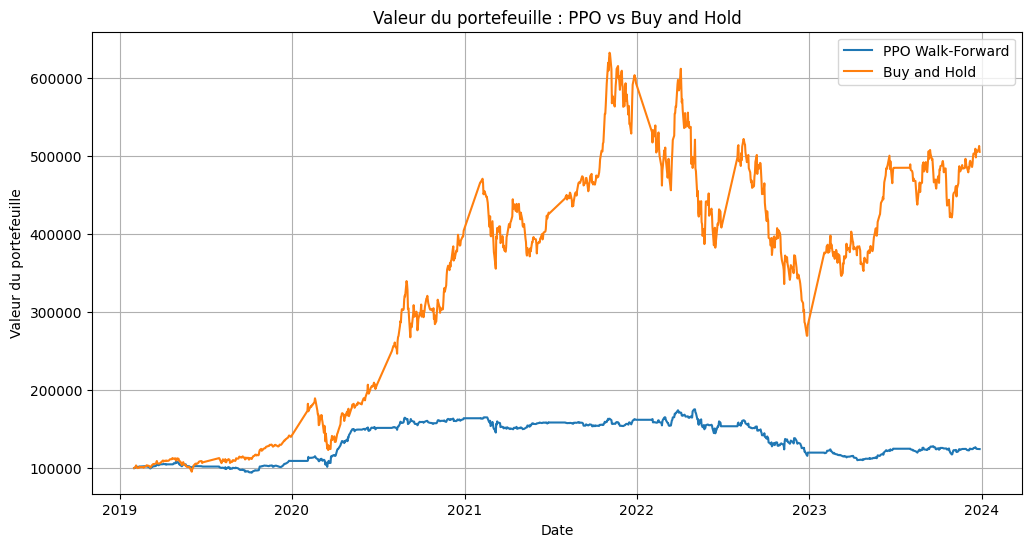

In [125]:
plt.figure(figsize=(12, 6))
plt.plot(comparison.index, comparison["ppo_portfolio"], label="PPO Walk-Forward")
plt.plot(comparison.index, comparison["buy_hold_portfolio"], label="Buy and Hold")
plt.title("Valeur du portefeuille : PPO vs Buy and Hold")
plt.xlabel("Date")
plt.ylabel("Valeur du portefeuille")
plt.legend()
plt.grid(True)
plt.show()

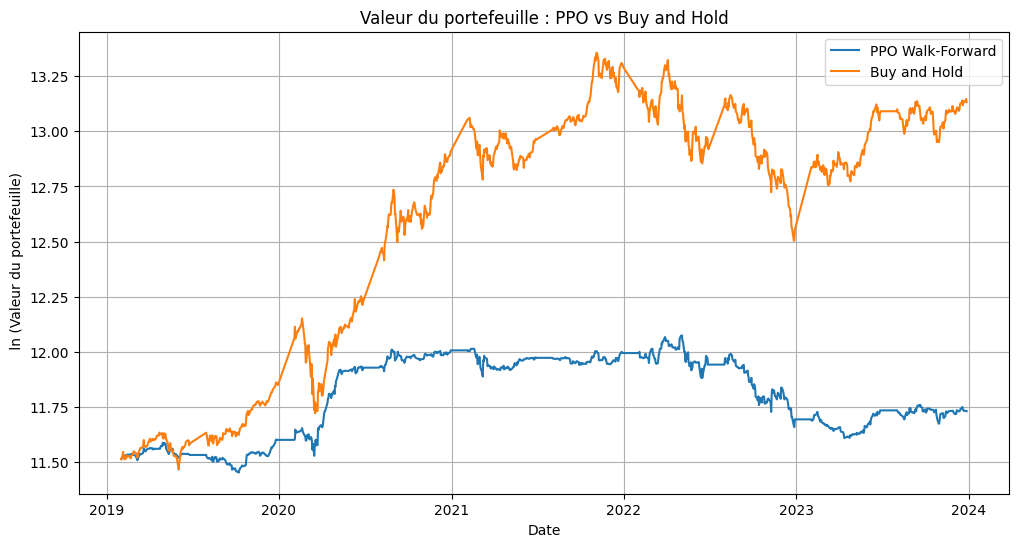

In [118]:
plt.figure(figsize=(12, 6))
plt.plot(comparison.index, np.log(comparison["ppo_portfolio"]), label="PPO Walk-Forward")
plt.plot(comparison.index, np.log(comparison["buy_hold_portfolio"]), label="Buy and Hold")
plt.title("Valeur du portefeuille : PPO vs Buy and Hold")
plt.xlabel("Date")
plt.ylabel(" ln (Valeur du portefeuille)")
plt.legend()
plt.grid(True)
plt.show()

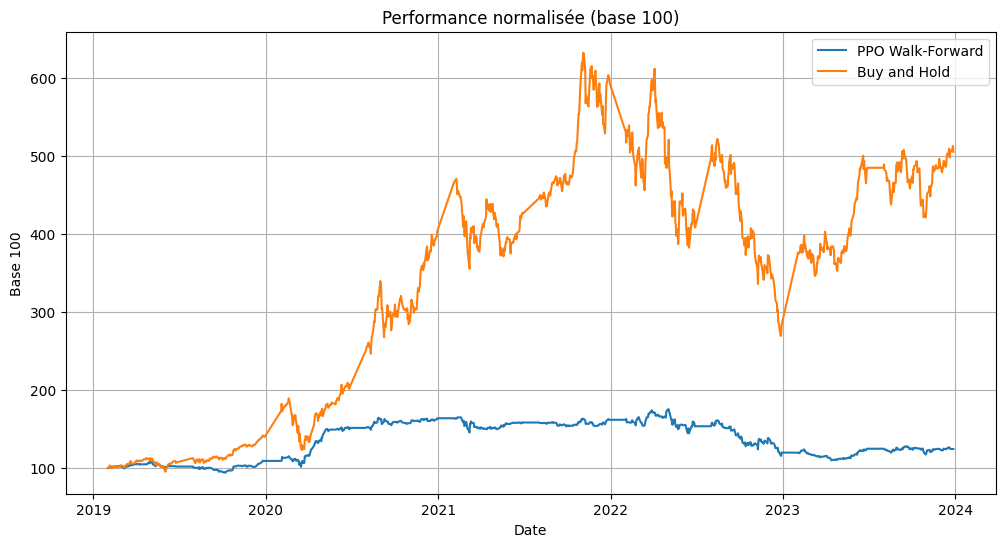

In [117]:
comparison_norm = comparison / comparison.iloc[0] * 100

plt.figure(figsize=(12, 6))
plt.plot(comparison_norm.index, comparison_norm["ppo_portfolio"], label="PPO Walk-Forward")
plt.plot(comparison_norm.index, comparison_norm["buy_hold_portfolio"], label="Buy and Hold")
plt.title("Performance normalisée (base 100)")
plt.xlabel("Date")
plt.ylabel("Base 100")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
def compute_curve_metrics(curve: pd.Series):
    returns = curve.pct_change().dropna()

    total_return = curve.iloc[-1] / curve.iloc[0] - 1.0

    sharpe = 0.0
    if returns.std() > 1e-12:
        sharpe = returns.mean() / returns.std() * np.sqrt(252)

    running_max = curve.cummax()
    drawdown = curve / running_max - 1.0
    max_drawdown = drawdown.min()

    return {
        "total_return": float(total_return),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_drawdown)
    }

In [37]:
ppo_metrics_global = compute_curve_metrics(comparison["ppo_portfolio"])
bh_metrics_global = compute_curve_metrics(comparison["buy_hold_portfolio"])

print("=== PPO Walk-Forward ===")
print(f"Total Return : {ppo_metrics_global['total_return']:.2%}")
print(f"Sharpe       : {ppo_metrics_global['sharpe']:.3f}")
print(f"Max DD       : {ppo_metrics_global['max_drawdown']:.2%}")

print("\n=== Buy and Hold ===")
print(f"Total Return : {bh_metrics_global['total_return']:.2%}")
print(f"Sharpe       : {bh_metrics_global['sharpe']:.3f}")
print(f"Max DD       : {bh_metrics_global['max_drawdown']:.2%}")

=== PPO Walk-Forward ===
Total Return : 62.36%
Sharpe       : 0.503
Max DD       : -57.34%

=== Buy and Hold ===
Total Return : 309.56%
Sharpe       : 1.003
Max DD       : -55.37%
